In [1]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import Subset

In [3]:
import matplotlib.pyplot as plt
import numpy as np

In [4]:
from tqdm import tqdm 

In [5]:
import random

In [6]:
from itertools import combinations

### Importing Data

In [7]:
# Transform images to tensors
transform = transforms.ToTensor()

# Load training dataset
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load test dataset
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

### Filtering Data

In [8]:
def FilterData(dataset, allowed_digits):

    labels = dataset.targets

    mask = torch.zeros_like(labels, dtype=torch.bool)

    for digit in allowed_digits:

        mask |= (labels == digit)

    indices = torch.where(mask)[0]

    filtered_dataset = Subset(dataset, indices)

    return filtered_dataset

In [9]:
def RandomSample(num_samples = 40, subset_size=5):

    N = num_samples
    k = subset_size

    if not isinstance(k, int):
        raise TypeError(f"for subset_size expected int, got {type(k).__name__}.")

    if not isinstance(N, int):
        raise TypeError(f"for num_samples expected int, got {type(N).__name__}.")

    if k > 5:
        raise ValueError(f"subset_size must be less than 5")

    if k < 0:
        raise ValueError(f"subset_size must be non-negative")

    if N < 0:
        raise ValueError(f"num_samples must be non-negative")


    sample_set = []
    complement_set = []

    X = range(10)

    for n in range(N):

        sample_indices = random.sample(X, k)

        sample_set.append(sample_indices)

        complement_indices = [i for i in X if i not in sample_indices]

        complement_set.append(complement_indices)

    return sample_set, complement_set

In [10]:
def TrainModel(model, training_data_loader, num_epochs):

    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    confusion_matrix_set = [np.zeros((10, 10)) for epoch in range(num_epochs)]

    for epoch in range(num_epochs):

        ############################
        #### TRAINING
        ############################

        model.train()

        total_loss = 0.0
        
        for inputs, labels in training_data_loader:

            outputs = model(inputs)

            loss = loss_function(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        #print(f"Epoch {epoch+1}, Total Training Loss: {total_loss:.4f}")

        ############################
        #### VALIDATING
        ############################

        model.eval()

        with torch.no_grad():
            
            all_true_labels = []
            all_predicted_labels = []

            for true_label in range(10):

                for inputs, labels in testing_partitions[true_label]:

                    outputs = model(inputs)

                    predictions = torch.argmax(outputs, dim=1)
  
                    all_true_labels.append(labels)
                    all_predicted_labels.append(predictions)

            all_true_labels = torch.cat(all_true_labels)
            all_predicted_labels = torch.cat(all_predicted_labels)

            num_images = len(all_true_labels)

            for n in range(num_images):

                true_label = all_true_labels[n]
                predicted_label = all_predicted_labels[n]

                confusion_matrix_set[epoch][predicted_label, true_label] += 1

    return model, confusion_matrix_set, all_true_labels, all_predicted_labels

In [33]:
def TrainEnsemble(num_samples=40, subset_size=5, num_epochs = 1):

    indices_set, complement_indices_set = RandomSample(num_samples, subset_size)

    overall_confusion_matrix = np.zeros((10,10))
    
    confusion_matrix_set = [np.zeros((10, 10)) for sample in range(num_samples)]

    for sample in tqdm(range(num_samples)):

        indices = indices_set[sample]
        complement_indices = complement_indices_set[sample]
        
        A = FilterData(train_dataset, indices)
        training_group_A = DataLoader(A, batch_size=64, shuffle=True)

        B = FilterData(train_dataset, complement_indices)
        training_group_B = DataLoader(B, batch_size=64, shuffle=True)

        print(indices_set[sample], complement_indices_set[sample])

        model = NeuralNetwork()

        
        #########################################################################################################################################
        #### TRAINING ON TASK A
        #########################################################################################################################################
        
        model_A, confusion_matrix_A, all_true_labels_A, all_predicted_labels_A = TrainModel(model, training_group_A, num_epochs)
                    
        #########################################################################################################################################
        #### TRAINING ON TASK B
        #########################################################################################################################################
        
        model_B, confusion_matrix_B, all_true_labels_B, all_predicted_labels_B = TrainModel(model_A, training_group_B, num_epochs)

        #########################################################################################################################################
        #### FILLING CONFUSION MATRIX
        #########################################################################################################################################
        
        num_images = len(all_predicted_labels_B)
        
        print(num_images)

        for n in range(num_images):

            predicted_label_A = all_predicted_labels_A[n]
            predicted_label_B = all_predicted_labels_B[n]
        
            confusion_matrix_set[sample][predicted_label_B, predicted_label_A] += 1
            overall_confusion_matrix[predicted_label_B, predicted_label_A] += 1

    return overall_confusion_matrix, confusion_matrix_set

In [34]:
overall_confusion_matrix, confusion_matrix_set = TrainEnsemble(num_samples=126, subset_size=5, num_epochs=1)

  0%|          | 0/126 [00:00<?, ?it/s]

[0, 7, 1, 8, 9] [2, 3, 4, 5, 6]


  1%|          | 1/126 [00:07<16:18,  7.83s/it]

10000
[3, 5, 2, 4, 9] [0, 1, 6, 7, 8]


  2%|▏         | 2/126 [00:15<16:33,  8.01s/it]

...

10000
[3, 2, 4, 7, 0] [1, 5, 6, 8, 9]


 99%|█████████▉| 125/126 [17:09<00:08,  8.34s/it]

10000
[4, 6, 7, 8, 2] [0, 1, 3, 5, 9]


100%|██████████| 126/126 [17:17<00:00,  8.23s/it]

10000


### Raw

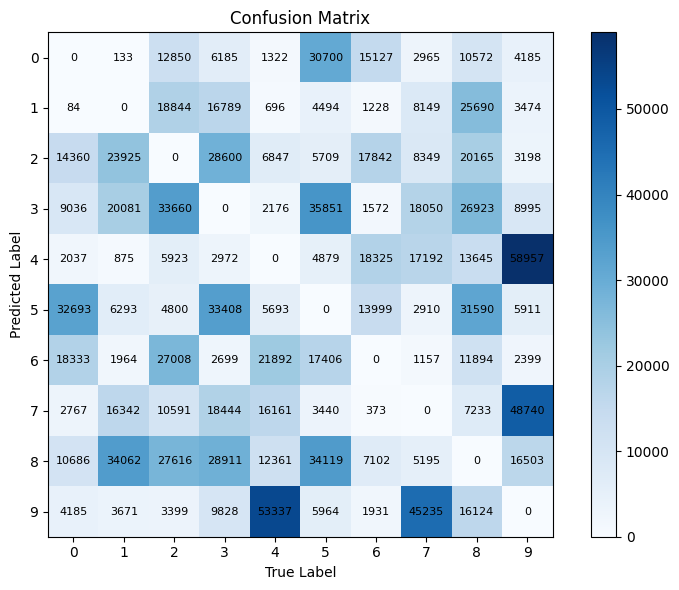

In [35]:
cm = overall_confusion_matrix

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm, cmap='Blues')

# Annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i,
            str(int(cm[i, j])),
            ha='center',
            va='center',
            color='black',
            fontsize=8
        )

ax.set_title("Confusion Matrix")
ax.set_xlabel("True Label")
ax.set_ylabel("Predicted Label")

# Optional: show class labels 0-9
ax.set_xticks(np.arange(cm.shape[1]))
ax.set_yticks(np.arange(cm.shape[0]))

# Add colorbar
fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

### Normalized

In [36]:
for col in range(10):

    n = np.sum(overall_confusion_matrix[:, col])

    for row in range(10):

        overall_confusion_matrix[row, col] = overall_confusion_matrix[row, col]/n

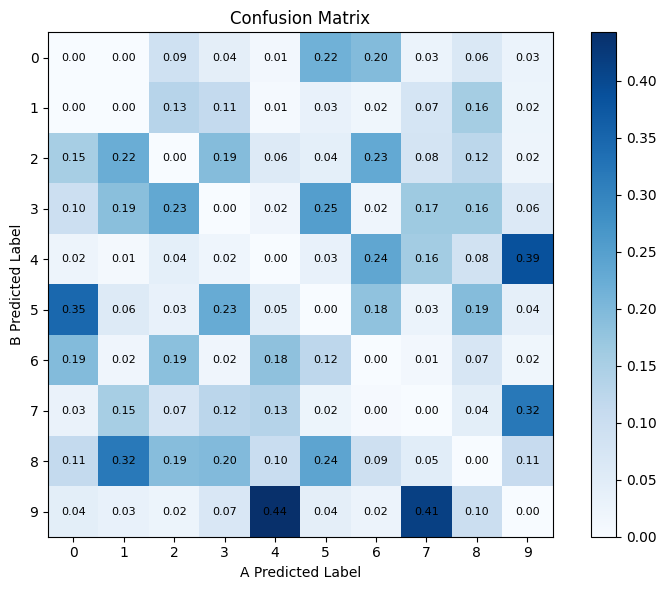

In [37]:
cm = overall_confusion_matrix

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm, cmap='Blues')

# Annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i,
            f"{cm[i, j]:.2f}",
            ha='center',
            va='center',
            color='black',
            fontsize=8
        )

ax.set_title("Confusion Matrix")
ax.set_xlabel("A Predicted Label")
ax.set_ylabel("B Predicted Label")

# Optional: show class labels 0-9
ax.set_xticks(np.arange(cm.shape[1]))
ax.set_yticks(np.arange(cm.shape[0]))

# Add colorbar
fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

### Training Data

In [38]:
training_digit_partitions = [[0, 1, 2], [3, 4, 5], [6, 7, 8, 9]]

In [39]:
training_partitions = []

In [40]:
num_training_groups= len(training_digit_partitions)

for i in range(num_training_groups):

    digit_partition = training_digit_partitions[i]

    X = FilterData(train_dataset, digit_partition)

    Y = DataLoader(X, batch_size=64, shuffle=True)

    training_partitions.append(Y)

### Testing Data

In [41]:
testing_digit_partitions = [[i] for i in range(10)]

In [42]:
testing_partitions = []

In [43]:
num_testing_groups = len(testing_digit_partitions)

for i in range(num_testing_groups):

    digit_partition = testing_digit_partitions[i]

    X = FilterData(test_dataset, digit_partition)

    Y = DataLoader(X, batch_size=64, shuffle=True)

    testing_partitions.append(Y)

In [44]:
for inputs, labels in training_partitions[2]:
    print(inputs.shape, labels.shape)
    print(labels)
    break
for inputs, labels in testing_partitions[9]:
    print(inputs.shape, labels.shape)
    print(labels)
    break

torch.Size([64, 1, 28, 28]) torch.Size([64])
tensor([7, 8, 6, 7, 9, 6, 9, 9, 9, 9, 8, 8, 7, 8, 8, 8, 7, 7, 8, 6, 8, 8, 7, 9,
        9, 6, 7, 9, 8, 9, 7, 9, 7, 7, 6, 9, 6, 7, 9, 8, 8, 8, 6, 9, 9, 7, 6, 6,
        8, 9, 8, 7, 7, 8, 7, 7, 7, 6, 6, 6, 9, 6, 6, 9])
torch.Size([64, 1, 28, 28]) torch.Size([64])
tensor([9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
        9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
        9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9])


### Data Info

In [45]:
total_num_training_images = 0
num_training_images = []

In [46]:
for i in range(num_training_groups):

    S = 0

    for inputs, labels in training_partitions[i]:

        S += len(labels)

    num_training_images.append(S)

    print(f"Number of training images in group {i+1}: {num_training_images[i]}")

    total_num_training_images += S

print()
print(f"Total number of training images: {total_num_training_images}")

Number of training images in group 1: 18623
Number of training images in group 2: 17394
Number of training images in group 3: 23983

Total number of training images: 60000


In [47]:
total_num_testing_images = 0
num_testing_images = []

In [48]:
for i in range(num_testing_groups):

    S = 0

    for inputs, labels in testing_partitions[i]:

        S += len(labels)

    num_testing_images.append(S)

    print(f"Number of testing images of {i}: {num_testing_images[i]}")

    total_num_testing_images += S

print()
print(f"Total number of testing images: {total_num_testing_images}")

Number of testing images of 0: 980
Number of testing images of 1: 1135
Number of testing images of 2: 1032
Number of testing images of 3: 1010
Number of testing images of 4: 982
Number of testing images of 5: 892
Number of testing images of 6: 958
Number of testing images of 7: 1028
Number of testing images of 8: 974
Number of testing images of 9: 1009

Total number of testing images: 10000


### Defining NN Architecure

In [49]:
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.relu = nn.ReLU()

        self.layer1 = nn.Linear(28*28, 128)
        self.layer2 = nn.Linear(128, 64)
        self.layer3 = nn.Linear(64, 10)

    def forward(self, X):

        X = self.flatten(X)

        X = self.layer1(X)
        X = self.relu(X)

        X = self.layer2(X)
        X = self.relu(X)

        X = self.layer3(X)

        logits = X

        return logits

    def hidden(self, X):

        X = self.flatten(X)

        X = self.layer1(X)
        X = self.relu(X)

        X = self.layer2(X)
        X = self.relu(X)

        hidden_representation = X

        return hidden_representation

### Training 

In [50]:
import copy

model = NeuralNetwork()

model_set = []

In [51]:
confusion_matrix_set_set = []

In [52]:
num_epochs = 3

In [53]:
for i in range(num_training_groups):
    
    trained_model, trained_confusion_matrix_set, all_true_labels, all_predicted_labels = TrainModel(model, training_partitions[i], num_epochs=3)

    model_set.append(copy.deepcopy(trained_model))
    confusion_matrix_set_set.append(trained_confusion_matrix_set)

In [54]:
for i in range(num_training_groups):

    print(model_set[i] is model)

False
False
False


### Confusion Matrix

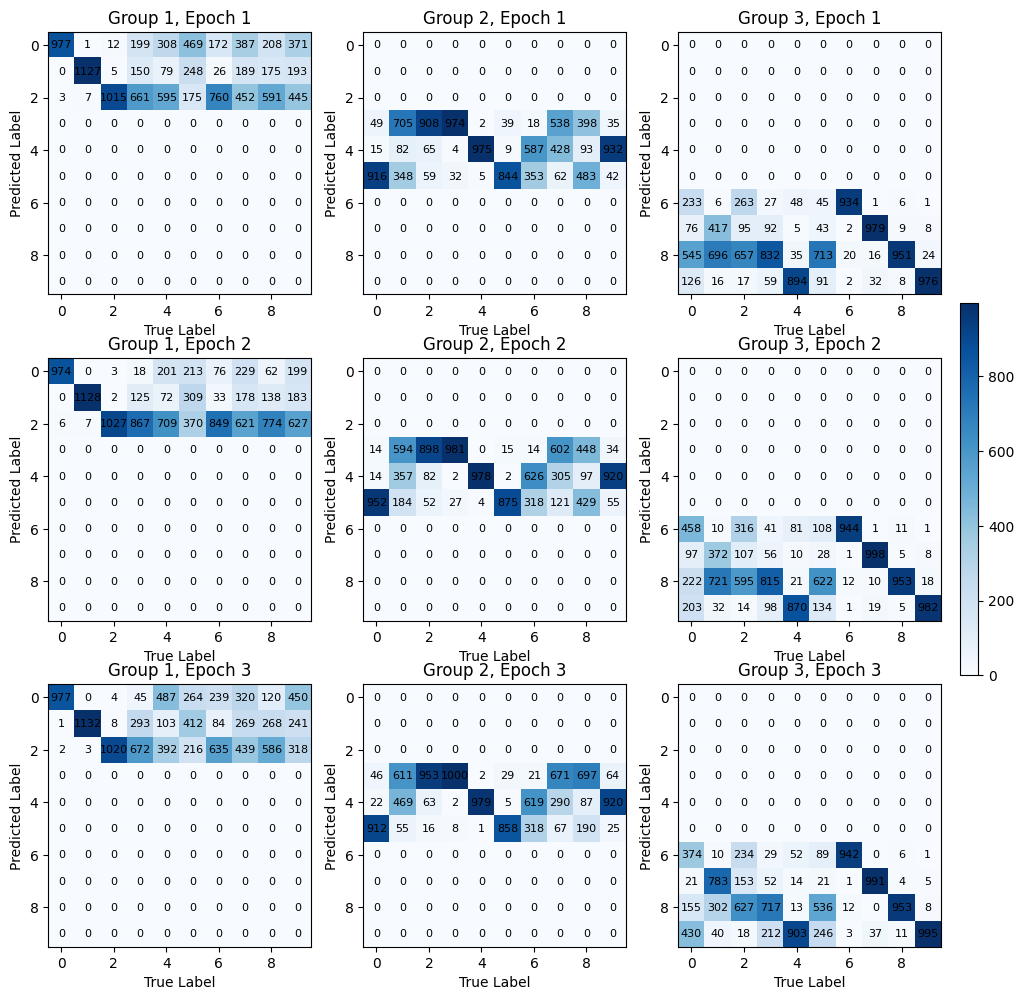

In [55]:
fig, axes = plt.subplots(
    nrows=num_epochs,
    ncols=num_training_groups,
    figsize=(4 * num_training_groups, 4 * num_epochs)
)

# Ensure axes is always 2D
axes = np.array(axes).reshape(num_epochs, num_training_groups)

for m in range(num_training_groups):          # columns = data types
    for n in range(num_epochs):     # rows = epochs

        ax = axes[n, m]
        cm = confusion_matrix_set_set[m][n]

        im = ax.imshow(cm, cmap='Blues')

        # annotate cells
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(
                    j, i,
                    str(int(cm[i, j])),
                    ha='center',
                    va='center',
                    color='black',
                    fontsize=8
                )

        ax.set_title(f"Group {m+1}, Epoch {n+1}")

        ax.set_xlabel("True Label")
        ax.set_ylabel("Predicted Label")

# One shared colorbar (important)
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)

plt.show()

### PCA Analyses of Penultimate Layer

### Learned PCA

In [63]:
PCA_set = []
embedded_data_set = []

In [64]:
num_components = 64

for training_group in range(num_training_groups):

    all_batches = []

    for digit in range(10):

        for inputs, labels in testing_partitions[digit]:

            hidden_outputs = model_set[training_group].hidden(inputs)

            all_batches.append(hidden_outputs.detach().numpy())

    data = np.concatenate(all_batches, axis = 0)

    standardizer = StandardScaler()
    standardized_data = standardizer.fit_transform(data)
    
    pca = PCA(n_components = num_components)
    embedded_data = pca.fit_transform(standardized_data)

    PCA_set.append(pca)
    embedded_data_set.append(embedded_data)

In [65]:
print(inputs.shape, labels.shape, hidden_outputs.shape, data.shape, embedded_data.shape, pca.components_.shape)

torch.Size([49, 1, 28, 28]) torch.Size([49]) torch.Size([49, 64]) (10000, 64) (10000, 64) (64, 64)


### Plotting Everything At Once

In [66]:
plotting_indices = np.cumsum(num_testing_images)
plotting_indices = np.insert(plotting_indices, 0, 0)

In [67]:
print(plotting_indices)

[    0   980  2115  3147  4157  5139  6031  6989  8017  8991 10000]


(10000, 64)
(10000, 64)
(10000, 64)


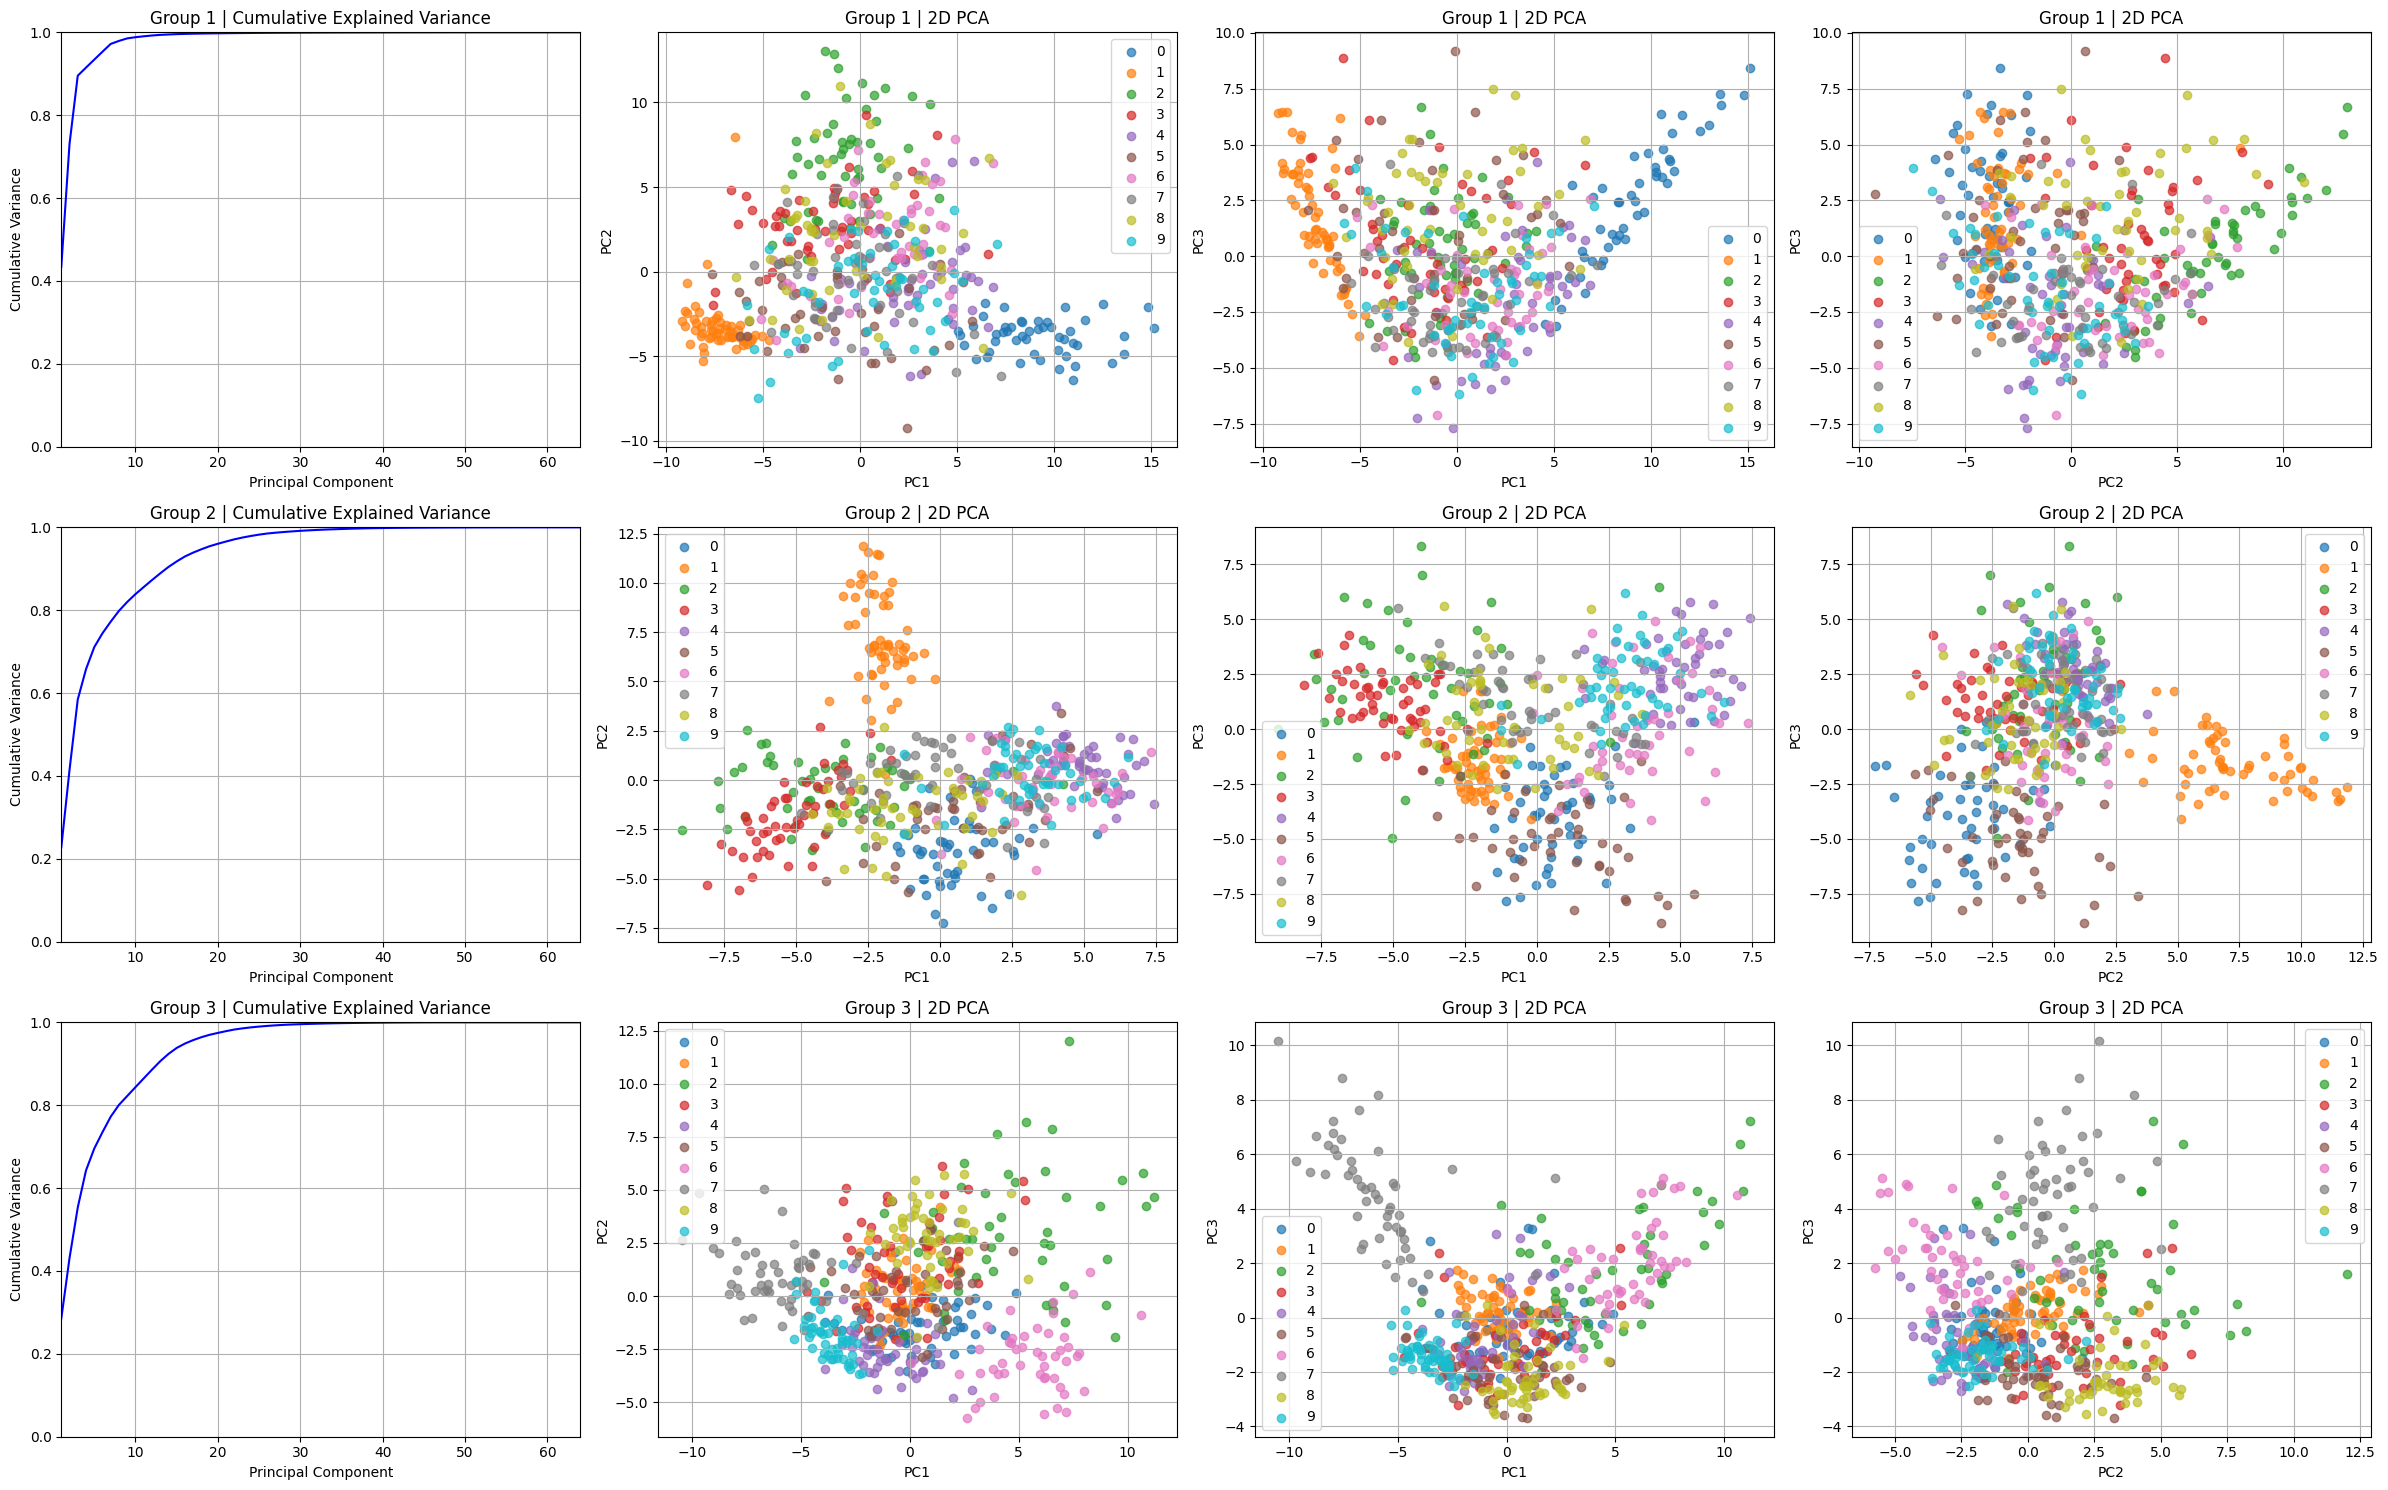

In [68]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plots

fig = plt.figure(figsize=(24, 5 * num_training_groups))  # tall figure for 10 rows

for training_group in range(num_training_groups):

    pca = PCA_set[training_group]
    embedded_data = embedded_data_set[training_group]

    print(embedded_data.shape)

    #################################################################
    # Subplot 1: Cumulative Explained Variance
    #################################################################
    ax1 = fig.add_subplot(num_training_groups, 4, training_group * 4 + 1)

    ax1.plot(
        np.arange(1, len(pca.explained_variance_ratio_) + 1),
        np.cumsum(pca.explained_variance_ratio_),
        color="Blue"
    )

    ax1.set_xlim(1, len(pca.explained_variance_ratio_))
    ax1.set_ylim(0, 1)
    ax1.grid(True)

    ax1.set_title(f"Group {training_group+1} | Cumulative Explained Variance")
    ax1.set_xlabel("Principal Component")
    ax1.set_ylabel("Cumulative Variance")

    #################################################################
    # Subplot 2: 2D PCA Scatter PCA 1/2
    #################################################################
    ax2 = fig.add_subplot(num_training_groups, 4, training_group * 4 + 2)
    
    for digit in range(10):
    
        ax2.scatter(
            embedded_data[plotting_indices[digit]:plotting_indices[digit+1]:20, 0],
            embedded_data[plotting_indices[digit]:plotting_indices[digit+1]:20, 1],
            alpha=0.7,
            label=str(digit)
        )


    ax2.set_title(f"Group {training_group+1} | 2D PCA")
    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")
    ax2.grid(True)
    ax2.legend()

    #################################################################
    # Subplot 3: 2D PCA Scatter PCA 1/3
    #################################################################
    ax3 = fig.add_subplot(num_training_groups, 4, training_group * 4 + 3)
    
    for digit in range(10):
    
        ax3.scatter(
            embedded_data[plotting_indices[digit]:plotting_indices[digit+1]:20, 0],
            embedded_data[plotting_indices[digit]:plotting_indices[digit+1]:20, 2],
            alpha=0.7,
            label=str(digit)
        )


    ax3.set_title(f"Group {training_group+1} | 2D PCA")
    ax3.set_xlabel("PC1")
    ax3.set_ylabel("PC3")
    ax3.grid(True)
    ax3.legend()

    #################################################################
    # Subplot 4: 2D PCA Scatter PCA 2/3
    #################################################################
    ax4 = fig.add_subplot(num_training_groups, 4, training_group * 4 + 4)
    
    for digit in range(10):
    
        ax4.scatter(
            embedded_data[plotting_indices[digit]:plotting_indices[digit+1]:20, 1],
            embedded_data[plotting_indices[digit]:plotting_indices[digit+1]:20, 2],
            alpha=0.7,
            label=str(digit)
        )


    ax4.set_title(f"Group {training_group+1} | 2D PCA")
    ax4.set_xlabel("PC2")
    ax4.set_ylabel("PC3")
    ax4.grid(True)
    ax4.legend()

# final layout
plt.tight_layout()
plt.show()

In [69]:
print(hidden_outputs.shape, data.shape)

torch.Size([49, 64]) (10000, 64)
